
# Breast Cancer Model — Training & Deployment Notebook

This notebook loads the **refined dataset** (`breast_cancer_aligned.csv`), performs preprocessing, trains a classification model, evaluates it, and exports a **single scikit-learn Pipeline** ready for deployment.  
It then generates a minimal **FastAPI** app (`app_fastapi.py`) that can serve predictions from the trained pipeline.

**Target:** `Outcome` (1 = positive, 0 = negative)  
**Features:** 
- `history_breast_cancer_or_radiation`
- `brca_mutation_or_genetic_syndrome`
- `age`
- `sub_ethnicity_or_birthplace`
- `biopsy_benign`
- `biopsy_benign_count`
- `biopsy_atypical_hyperplasia`
- `age_first_menstrual`
- `age_first_childbirth`
- `relatives_breast_cancer`


In [8]:

# === Setup ===
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

# Path to the refined dataset
CSV_PATH = r"/Users/romun/Downloads/test/breast_cancer_aligned.csv"
assert Path(CSV_PATH).exists(), "Dataset not found. Make sure 'breast_cancer_aligned.csv' is present."
print("Using dataset:", CSV_PATH)


Using dataset: /Users/romun/Downloads/test/breast_cancer_aligned.csv


In [3]:

# === Load & Inspect ===
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head()


Shape: (2000, 11)


,history_breast_cancer_or_radiation,brca_mutation_or_genetic_syndrome,age,sub_ethnicity_or_birthplace,biopsy_benign,biopsy_benign_count,biopsy_atypical_hyperplasia,age_first_menstrual,age_first_childbirth,relatives_breast_cancer,Outcome
0,No,Unknown,79,Njombe,No,1,No,9,22,Unknown,1
1,No,No,62,Geita,Yes,1,Yes,14,32,Unknown,0
2,No,Unknown,85,Songwe,Yes,0,Yes,13,39,NaN,1
3,No,Yes,52,Njombe,Unknown,1,No,12,28,More than one,0
4,No,No,68,Geita,No,1,No,12,21,More than one,1


In [4]:

# === Columns & Types ===
target_col = "Outcome"
feature_cols = [
    "history_breast_cancer_or_radiation",
    "brca_mutation_or_genetic_syndrome",
    "age",
    "sub_ethnicity_or_birthplace",
    "biopsy_benign",
    "biopsy_benign_count",
    "biopsy_atypical_hyperplasia",
    "age_first_menstrual",
    "age_first_childbirth",
    "relatives_breast_cancer",
]

# Identify categorical vs numeric columns
categorical_cols = [
    "history_breast_cancer_or_radiation",
    "brca_mutation_or_genetic_syndrome",
    "sub_ethnicity_or_birthplace",
    "biopsy_benign",
    "biopsy_atypical_hyperplasia",
    "relatives_breast_cancer",
]

numeric_cols = [
    "age",
    "biopsy_benign_count",
    "age_first_menstrual",
    "age_first_childbirth",
]

# Basic validation
missing_cols = [c for c in feature_cols + [target_col] if c not in df.columns]
assert not missing_cols, f"Missing required columns: {missing_cols}"
assert set(df[target_col].dropna().unique()).issubset({0,1}), "Outcome must be 0/1"


In [5]:

# === Train / Test Split ===
X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((1600, 10), (400, 10))

In [6]:

# === Preprocessing ===
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numeric_transformer, numeric_cols),
    ]
)

# === Model ===
# Start with Logistic Regression; later you can switch to RandomForest if needed.
log_reg = LogisticRegression(max_iter=1000, n_jobs=None)

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", log_reg)
])

# Cross-validated ROC-AUC (quick check)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(clf, X_train, y_train, scoring="roc_auc", cv=cv, n_jobs=-1)
print("CV ROC-AUC (mean ± std):", np.round(cv_auc.mean(),4), "±", np.round(cv_auc.std(),4))

# Fit on full training set
clf.fit(X_train, y_train)


CV ROC-AUC (mean ± std): 0.4565 ± 0.0107


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['history_breast_cancer_or_radiation',
                                                   'brca_mutation_or_genetic_syndrome',
                                                   'sub_ethnicity_or_birthplace',
                                                   'biopsy_benign',
                                                   'biopsy_atypical_hyperplasia',
                                                   'relatives_breast_cancer']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'biopsy_benign_count',
                                                   'age_first_menstrual',
                                                   'age_first_childbirth'])])),
                ('model', LogisticRegression(max_iter=1000))])

Classification Report:
               precision    recall  f1-score   support

           0     0.4862    0.4400    0.4619       200
           1     0.4886    0.5350    0.5107       200

    accuracy                         0.4875       400
   macro avg     0.4874    0.4875    0.4863       400
weighted avg     0.4874    0.4875    0.4863       400

ROC-AUC: 0.4982
Confusion Matrix:
 [[ 88 112]
 [ 93 107]]


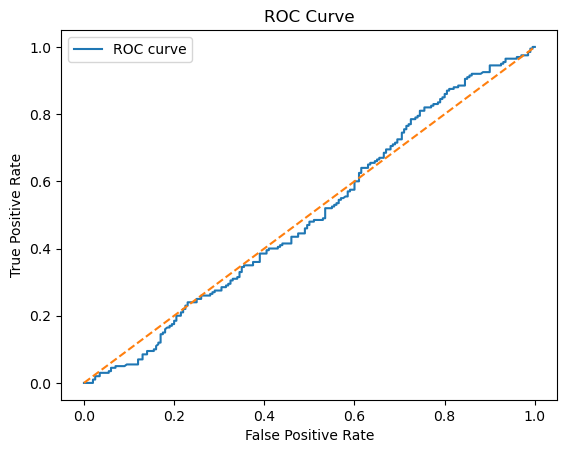

In [7]:

# === Evaluation ===
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", np.round(roc_auc_score(y_test, y_proba), 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ROC Curve (single plot, no custom colors)
fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [9]:

# === Save Trained Pipeline ===
from pathlib import Path
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / "breast_cancer_pipeline.pkl"
joblib.dump(clf, model_path)
print("Saved pipeline to:", model_path.resolve())

# Example inference payload
example = X_test.iloc[0].to_dict()
print("Example input:", example)
print("Predicted class:", int(clf.predict(pd.DataFrame([example]))[0]))
print("Predicted proba:", float(clf.predict_proba(pd.DataFrame([example]))[0,1]))


Saved pipeline to: C:\Users\romun\Downloads\test\artifacts\breast_cancer_pipeline.pkl
Example input: {'history_breast_cancer_or_radiation': 'No', 'brca_mutation_or_genetic_syndrome': 'No', 'age': 41, 'sub_ethnicity_or_birthplace': 'Kigoma', 'biopsy_benign': 'No', 'biopsy_benign_count': 1, 'biopsy_atypical_hyperplasia': 'No', 'age_first_menstrual': 9, 'age_first_childbirth': 40, 'relatives_breast_cancer': 'Unknown'}
Predicted class: 1
Predicted proba: 0.558655304966516
